# PyKoopman: Time Delays

> We use our training data to fit a DMD model by using time embeddings and a single trajectory.

#### Imports

In [2]:
from ast import literal_eval

import matplotlib.pyplot as plt
import numpy as np
import numpy.random as rnd
import pykoopman as pk
from matrepr import mprint
from pydmd import DMD
from safetensors.torch import load_file

from learningdynamics.utils import safetensors_metadata_parser
from learningdynamics.dmd_dataset import reshape_interleave_time

In [3]:
# | hide
np.random.seed(42)  # for reproducibility
%matplotlib inline

#### Load data

The data is stored in 2D [states x length]

each block in the second dimension corresponds to a step for the n_traj

In [4]:
file_path = "../saved_weights/mnist_states.safetensors"

metadata = safetensors_metadata_parser(file_path=file_path)
NUM_LOOP_ITERATIONS = literal_eval(metadata["NUM_LOOP_ITERATIONS"])
NUM_TRAJECTORIES = literal_eval(metadata["NUM_TRAJECTORIES"])
NUM_STATES = literal_eval(metadata["NUM_STATES"])

data = load_file(file_path)

#### Update dataset

In [5]:
# train_idx = np.random.choice(NUM_TRAJECTORIES)
train_idx = 8

In [6]:
# test_idx = np.random.choice(NUM_TRAJECTORIES)
test_idx = 2

In [7]:
NUM_TRAJECTORIES = 1
NUM_LOOP_ITERATIONS = 15

NUM_DELAYS = 2
# NUM_DELAYS = int(NUM_LOOP_ITERATIONS * 0.6)
RANK = 30

In [8]:
t = np.arange(0, NUM_LOOP_ITERATIONS, 1)

#### Learn Koopman Operator

Using time delay observables

In [9]:
train_states = reshape_interleave_time(
    data["train_states"][:NUM_LOOP_ITERATIONS, [train_idx], :]
)
test_states = reshape_interleave_time(
    data["test_states"][:NUM_LOOP_ITERATIONS, [test_idx], :]
)
observables = pk.observables.TimeDelay(n_delays=NUM_DELAYS)

In [10]:
regressor = pk.regression.EDMD(svd_rank=RANK)
# regressor = DMD(svd_rank=RANK)

# Time shift data
X = train_states[:, :-NUM_TRAJECTORIES].numpy()
Y = train_states[:, NUM_TRAJECTORIES:].numpy()

dmd_model = pk.Koopman(observables=observables, regressor=regressor)
dmd_model.fit(X.T)

Koopman(observables=TimeDelay(), regressor=EDMD(svd_rank=30))

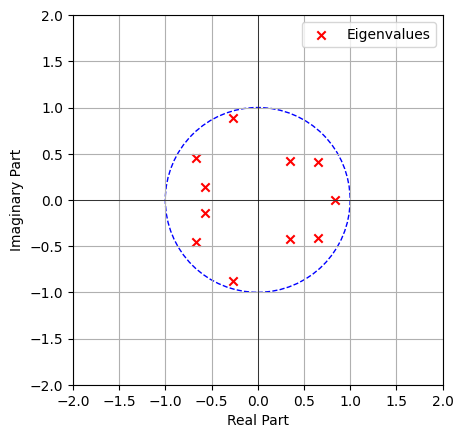

In [11]:
# Assuming koop_eigenvals is already defined
koop_eigenvals = np.linalg.eig(dmd_model.A)[0]

# Create the figure and axis
fig, ax = plt.subplots()

# Plot the unit circle
unit_circle = plt.Circle((0, 0), 1, color="b", fill=False, linestyle="--")
ax.add_artist(unit_circle)

# Plot the eigenvalues
ax.scatter(
    koop_eigenvals.real, koop_eigenvals.imag, color="r", marker="x", label="Eigenvalues"
)

# Set the axis limits
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])

# Add grid, legend, and labels
ax.grid(True)
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")
ax.legend()

# Show the plot
plt.show()

In [12]:
mprint(dmd_model.A)

<11×11, 121 'float32' elements, array>
         0           1         2              8         9         10
   ┌                                                                     ┐
 0 │   0.907      0.02586   0.05097   ...  -0.09007  0.05426   -0.06784  │
 1 │   -0.163     -0.2166   -0.3625   ...  -0.09411   0.1095    0.2544   │
 2 │  -0.02814    0.7886    -0.07211  ...  -0.2038   0.009997  -0.06889  │
 3 │  0.004122    -0.2014   -0.05999  ...  -0.1349   -0.2101    0.2692   │
 4 │  0.01221    -0.01384    0.1573   ...  -0.08218   0.1264    0.03744  │
 5 │ 0.0002461   0.007799   -0.0807   ...   0.1201   -0.03095   -0.2034  │
 6 │  0.002041    -0.0239    0.6173   ...  -0.02476  -0.0532   -0.001854 │
 7 │  0.008978   -0.003046  -0.3007   ...  0.05264   0.01883   -0.06571  │
 8 │  -0.00289   0.008191    0.1852   ...  -0.5117    0.2769    0.2238   │
 9 │ -0.003895   0.001267   0.09888   ...   0.6546    0.2106    0.3807   │
10 │ -0.0005535   0.00128   0.01878   ...  0.03188   -0.4775    0.1

In [13]:
train_states.shape

torch.Size([16, 15])

/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:292: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)


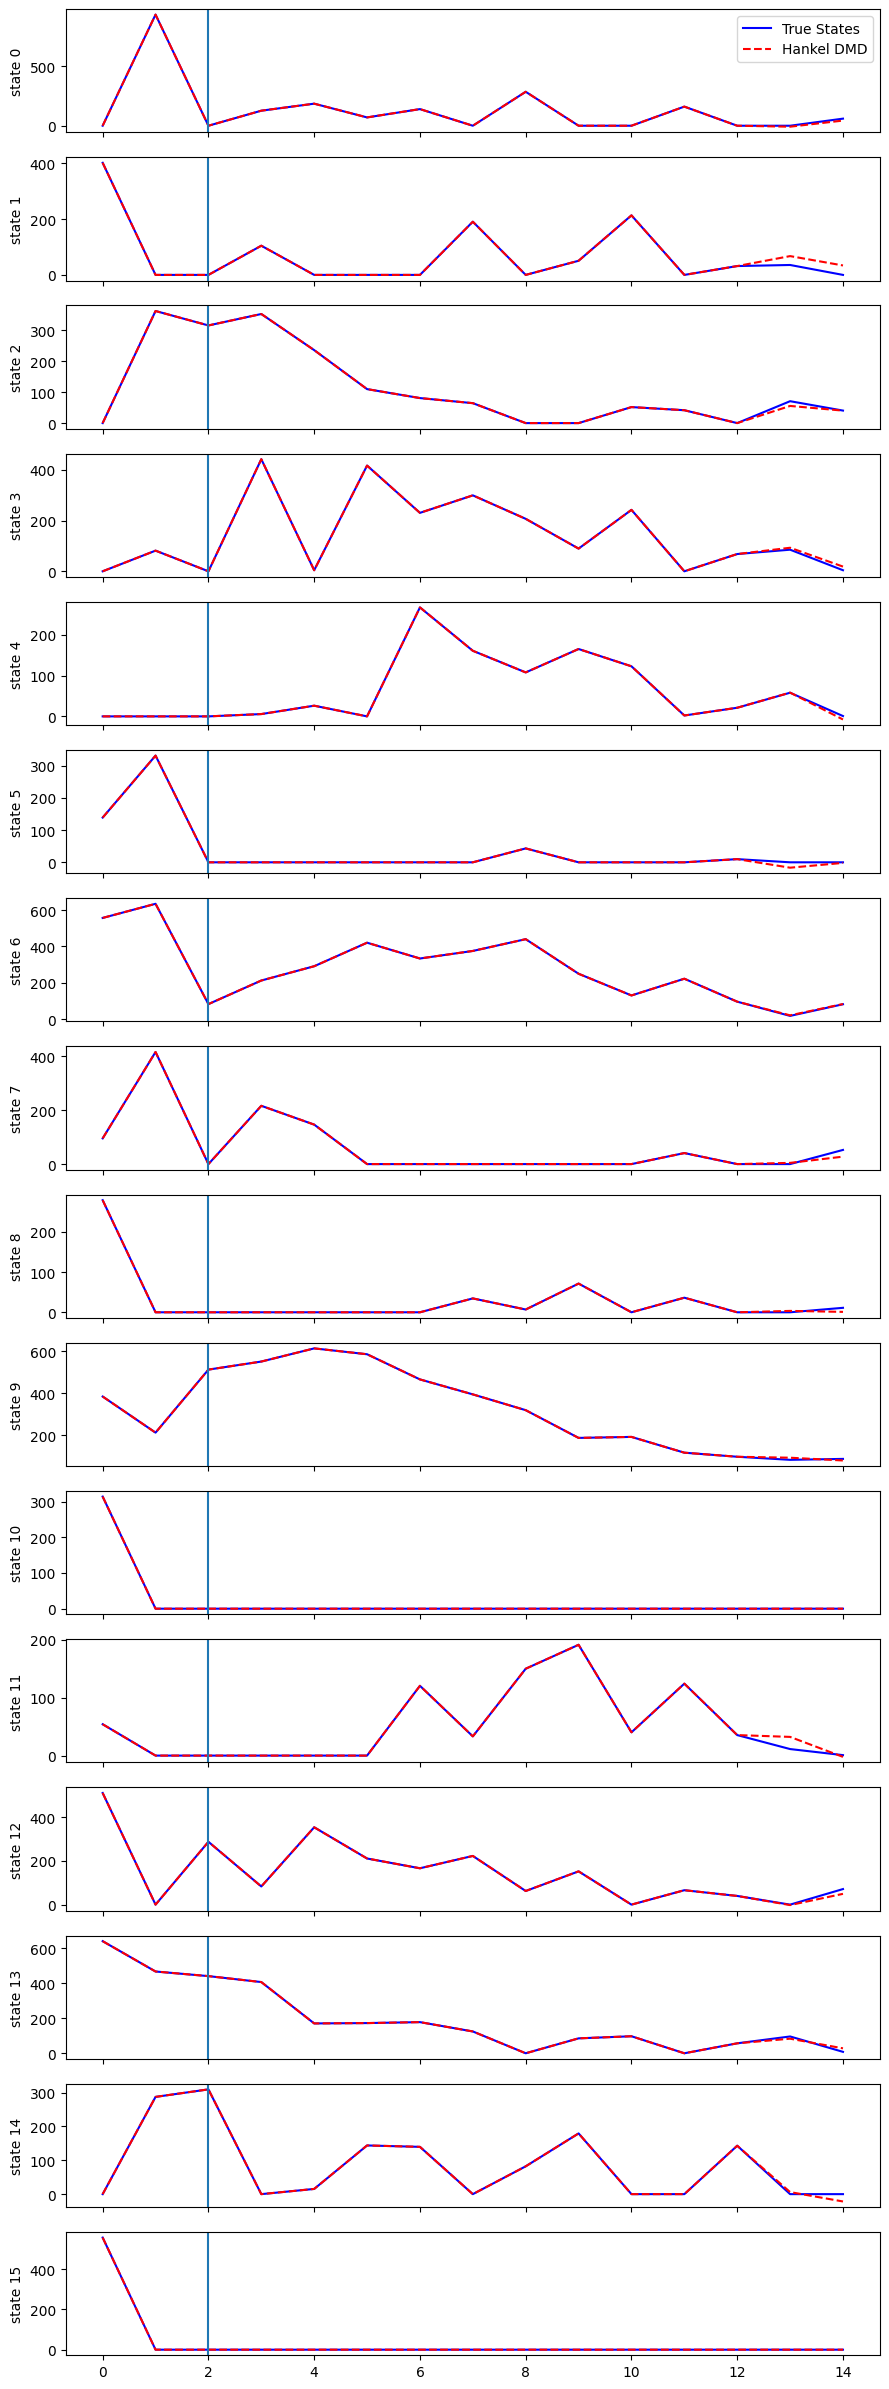

In [14]:
x0_td = train_states[:, : NUM_DELAYS + 1].T.numpy()
Xkoop = dmd_model.simulate(x0_td, n_steps=NUM_LOOP_ITERATIONS - 1 - NUM_DELAYS)
Xkoop = np.vstack([x0_td, Xkoop])

fig, axs = plt.subplots(NUM_STATES, 1, sharex=True, tight_layout=True, figsize=(9, 24))

for state_idx in range(0, NUM_STATES):
    axs[state_idx].plot(
        t, train_states[state_idx, :], "-", color="b", label="True States"
    )
    axs[state_idx].plot(t, Xkoop[:, state_idx], "--r", label="Hankel DMD")
    axs[state_idx].set(ylabel=f"state {state_idx}")

for i in range(0, NUM_STATES):
    axs[i].axvline(x=t[NUM_DELAYS])
axs[0].legend()

/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:292: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)


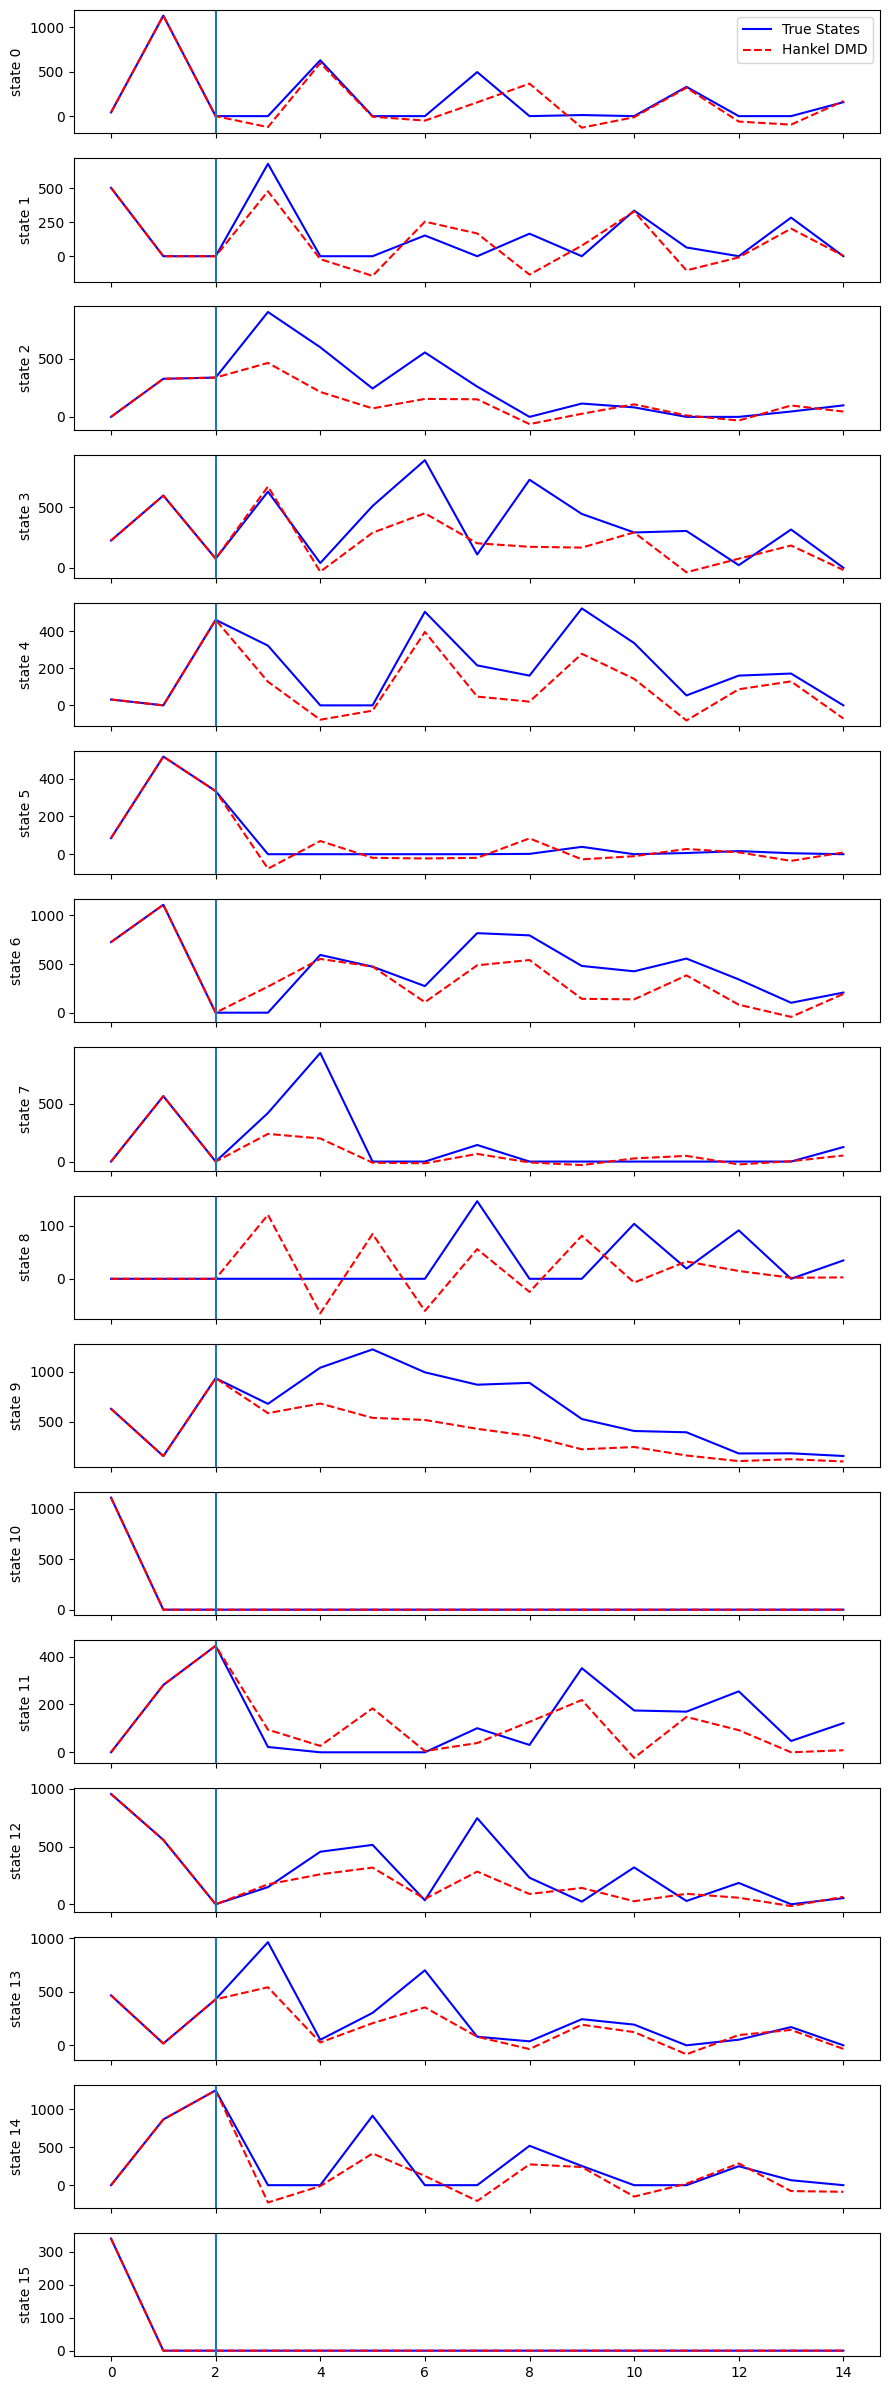

In [15]:
x0_td = test_states[:, : NUM_DELAYS + 1].T.numpy()
Xkoop = dmd_model.simulate(x0_td, n_steps=NUM_LOOP_ITERATIONS - 1 - NUM_DELAYS)
Xkoop = np.vstack([x0_td, Xkoop])

fig, axs = plt.subplots(NUM_STATES, 1, sharex=True, tight_layout=True, figsize=(9, 24))

for state_idx in range(0, NUM_STATES):
    axs[state_idx].plot(
        t, test_states[state_idx, :], "-", color="b", label="True States"
    )
    axs[state_idx].plot(t, Xkoop[:, state_idx], "--r", label="Hankel DMD")
    axs[state_idx].set(ylabel=f"state {state_idx}")

for i in range(0, NUM_STATES):
    axs[i].axvline(x=t[NUM_DELAYS])
axs[0].legend()

Matrix A:
[[ 9.07043815e-01  2.58564427e-02  3.44367549e-02  2.94048995e-01
  -4.03360613e-02  5.09677082e-02  1.20410807e-02 -4.78606932e-02
  -9.00748074e-02  5.42624369e-02 -6.78391978e-02]
 [-1.63046345e-01 -2.16550350e-01  9.94439349e-02  8.32701195e-03
   2.06622064e-01 -3.62516582e-01 -4.37972695e-01 -1.93232208e-01
  -9.41088051e-02  1.09471150e-01  2.54365802e-01]
 [-2.81368364e-02  7.88599610e-01  3.43070954e-01 -1.87655073e-02
  -2.43917461e-02 -7.21098036e-02 -4.55864370e-02  3.24392259e-01
  -2.03757659e-01  9.99747496e-03 -6.88896254e-02]
 [ 4.12191125e-03 -2.01413393e-01  6.67628706e-01  1.62722751e-01
  -1.92648575e-01 -5.99944927e-02  3.94270957e-01 -1.94938079e-01
  -1.34912789e-01 -2.10074738e-01  2.69233167e-01]
 [ 1.22102350e-02 -1.38447434e-02  4.34412919e-02 -7.28353202e-01
  -2.76837468e-01  1.57293111e-01  9.28688645e-02 -2.63809770e-01
  -8.21826309e-02  1.26396462e-01  3.74399275e-02]
 [ 2.46062991e-04  7.79853016e-03 -2.71553285e-02  8.57232437e-02
  -5.7371